# RealMistake Full Dataset Analysis

Exploratory analysis of `data/realmistake_full.csv`: label balance, model breakdown, task types, and prompt length patterns.

In [1]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "realmistake_full.csv"
REALMISTAKE_DIR = PROJECT_ROOT / "data" / "realmistake"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,question,llm_model,error
0,Generate a math word problem that satisfies th...,meta-llama/Llama-2-70b-chat-hf,error
1,Generate a math word problem that satisfies th...,meta-llama/Llama-2-70b-chat-hf,error
2,Generate a math word problem that satisfies th...,meta-llama/Llama-2-70b-chat-hf,no_error
3,Generate a math word problem that satisfies th...,meta-llama/Llama-2-70b-chat-hf,error
4,Generate a math word problem that satisfies th...,meta-llama/Llama-2-70b-chat-hf,error


## Dataset overview

In [3]:
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print()
print(df.dtypes)
print()
print("Missing values:")
print(df.isnull().sum())

Rows: 900
Columns: ['question', 'llm_model', 'error']

question     object
llm_model    object
error        object
dtype: object

Missing values:
question     0
llm_model    0
error        0
dtype: int64


In [4]:
df["question_chars"] = df["question"].str.len()
df["question_words"] = df["question"].str.split().str.len()
df["is_error"] = df["error"] == "error"

df[["question_chars", "question_words"]].describe().round(1)

,question_chars,question_words
count,900.0,900.0
mean,1778.4,292.9
std,1005.2,173.4
min,645.0,103.0
25%,744.0,119.0
50%,1726.0,271.0
75%,2986.0,509.0
max,3869.0,599.0


## Error label distribution

In [5]:
label_counts = df["error"].value_counts()
label_pct = (label_counts / len(df) * 100).round(1)
summary = pd.DataFrame({"count": label_counts, "pct": label_pct})
summary

,count,pct
error,,
error,649,72.1
no_error,251,27.9


/var/folders/bp/p_1nzxj96b7gxxrykwzbq04r0000gn/T/ipykernel_45392/2989509726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="error", order=["error", "no_error"], palette="Set2", ax=ax)


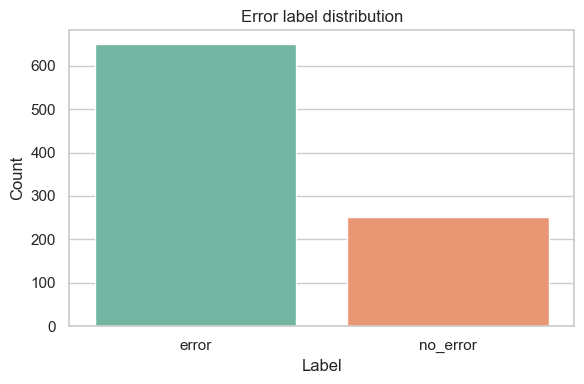

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="error", order=["error", "no_error"], palette="Set2", ax=ax)
ax.set_title("Error label distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Model breakdown

In [7]:
model_counts = df["llm_model"].value_counts()
model_counts

llm_model
meta-llama/Llama-2-70b-chat-hf    480
gpt-4-0613                        420
Name: count, dtype: int64

In [8]:
model_error = (
    df.groupby("llm_model", as_index=False)["is_error"]
    .agg(error_rate="mean", n="count")
    .sort_values("error_rate", ascending=False)
)
model_error["error_rate"] = (model_error["error_rate"] * 100).round(1)
model_error

,llm_model,error_rate,n
1,meta-llama/Llama-2-70b-chat-hf,80.6,480
0,gpt-4-0613,62.4,420


/var/folders/bp/p_1nzxj96b7gxxrykwzbq04r0000gn/T/ipykernel_45392/3940881805.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


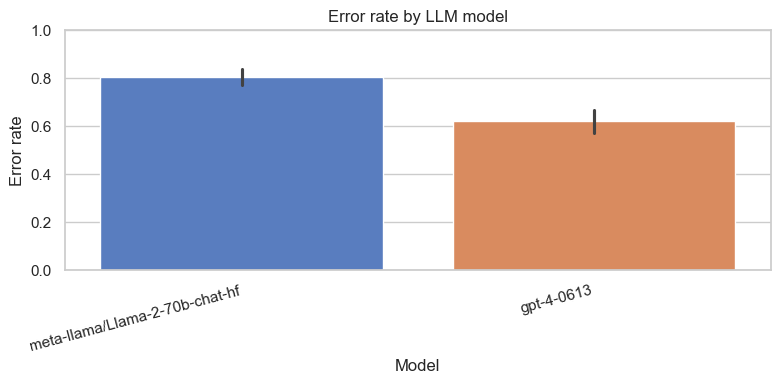

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=df,
    x="llm_model",
    y="is_error",
    estimator="mean",
    errorbar="ci",
    palette="muted",
    ax=ax,
)
ax.set_title("Error rate by LLM model")
ax.set_xlabel("Model")
ax.set_ylabel("Error rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Task breakdown

Task names are recovered from the source JSONL files used to build the CSV.

In [10]:
TASK_DIRS = [
    "math_word_problem_generation",
    "finegrained_fact_verification",
    "answerability_classification",
]

task_rows = []
for task_dir in TASK_DIRS:
    for path in sorted((REALMISTAKE_DIR / task_dir).glob("*.jsonl")):
        with path.open(encoding="utf-8") as f:
            for line in f:
                row = json.loads(line)
                task_rows.append(
                    {
                        "question": row["input"].strip(),
                        "llm_model": row["metadata"]["llm_response_model"],
                        "error": row["error_label"],
                        "task": task_dir,
                    }
                )

task_df = pd.DataFrame(task_rows)
assert len(task_df) == len(df), "CSV row count does not match source JSONL"

df = df.drop(columns=["task"], errors="ignore").merge(
    task_df[["question", "llm_model", "error", "task"]],
    on=["question", "llm_model", "error"],
    how="left",
)
df["task"].value_counts()

task
math_word_problem_generation     300
finegrained_fact_verification    300
answerability_classification     300
Name: count, dtype: int64

In [11]:
task_error = (
    df.groupby("task", as_index=False)["is_error"]
    .agg(error_rate="mean", n="count")
    .sort_values("error_rate", ascending=False)
)
task_error["error_rate"] = (task_error["error_rate"] * 100).round(1)
task_error

,task,error_rate,n
0,answerability_classification,72.3,300
1,finegrained_fact_verification,72.3,300
2,math_word_problem_generation,71.7,300


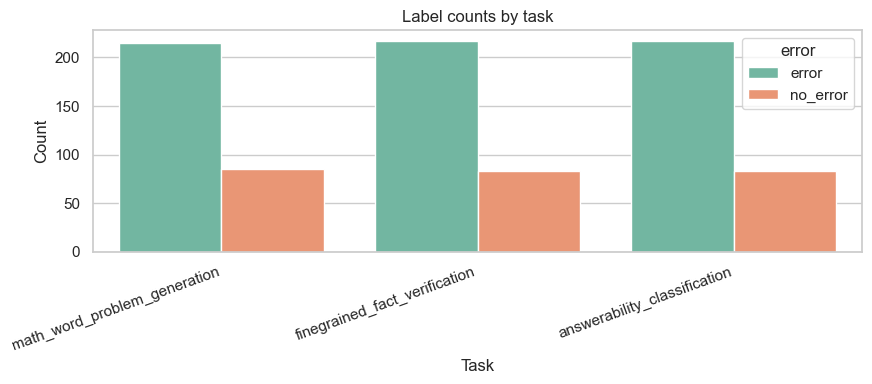

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.countplot(data=df, x="task", hue="error", hue_order=["error", "no_error"], palette="Set2", ax=ax)
ax.set_title("Label counts by task")
ax.set_xlabel("Task")
ax.set_ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Task x model error rate

In [13]:
cross = (
    df.groupby(["task", "llm_model"])["is_error"]
    .mean()
    .unstack()
    .round(3)
)
cross

llm_model,gpt-4-0613,meta-llama/Llama-2-70b-chat-hf
task,,
answerability_classification,0.621,0.812
finegrained_fact_verification,0.629,0.806
math_word_problem_generation,0.621,0.800


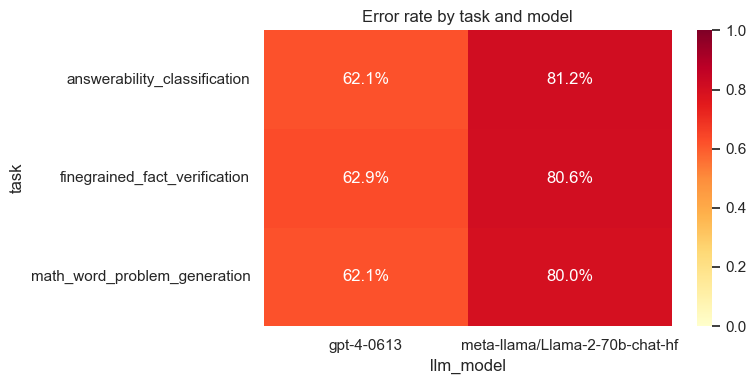

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(cross, annot=True, fmt=".1%", cmap="YlOrRd", vmin=0, vmax=1, ax=ax)
ax.set_title("Error rate by task and model")
plt.tight_layout()
plt.show()

## Prompt length analysis

In [ ]:
length_by_label = df.groupby("error")[["question_chars", "question_words"]].describe().round(1)
length_by_label

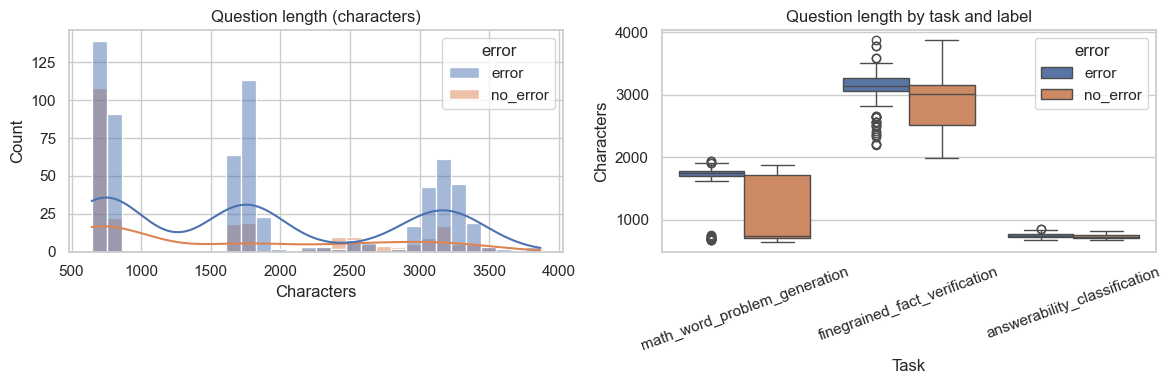

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="question_chars", hue="error", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Question length (characters)")
axes[0].set_xlabel("Characters")

sns.boxplot(data=df, x="task", y="question_chars", hue="error", hue_order=["error", "no_error"], ax=axes[1])
axes[1].set_title("Question length by task and label")
axes[1].set_xlabel("Task")
axes[1].set_ylabel("Characters")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Sample prompts

In [16]:
def show_sample(task_name, label, n_chars=400):
    row = df[(df["task"] == task_name) & (df["error"] == label)].iloc[0]
    print(f"task: {row['task']}")
    print(f"model: {row['llm_model']}")
    print(f"label: {row['error']}")
    print(f"question ({row['question_chars']} chars):")
    print(row["question"][:n_chars] + "...")
    print()

for task in df["task"].unique():
    show_sample(task, "error")
    show_sample(task, "no_error")

task: math_word_problem_generation
model: meta-llama/Llama-2-70b-chat-hf
label: error
question (1758 chars):
Generate a math word problem that satisfies the following requirements. First, provide the generated question. Second, generate a step-by-step solution for the generated question.

* When the requirements instruct only to use integers in the problem or solution, you may use integers with units (e.g., 15kg, 10%) but should not use fractions (e.g., 1/2) if not specified. This applies to all data typ...

task: math_word_problem_generation
model: meta-llama/Llama-2-70b-chat-hf
label: no_error
question (652 chars):
Generate a math word problem that satisfies the following requirements. You only need to generate a question. You do not need to generate a solution for the question.

General Requirements:
* The generated question should be valid and answerable.
* The generated question should not be ambiguous and the final answer to the generated questions must be unique.
* The generated